# 01. Dataset Exploration & Topology Analysis

## Grounded Customer Support Agent

**Author:** Senior AI/ML Engineering Candidate  
**Dataset:** Customer Support on Twitter (`thoughtvector/customer-support-on-twitter`)  
**Milestone:** Phase 1 – Dataset Exploration Pipeline

---

### Objectives
1. Audit the scale, schema integrity, and temporal span of the 2.81M tweet dataset.
2. Map conversation topology (root inquiries, conversational turns, thread branches).
3. Identify top support brands and evaluate behavioral response patterns.
4. Analyze resolution cues (knowledge base URLs, private DM handoffs, customer resolution confirmations).
5. Establish candidate brands for single-brand grounded agent selection (Phase 2).


In [1]:
import json
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Ensure project root is in sys.path
for p in ['.', '..']:
    if Path(p).resolve() not in [Path(x).resolve() for x in sys.path]:
        sys.path.insert(0, str(Path(p).resolve()))
from scripts.data.loader import get_dataset_path, load_sample_data  # noqa: E402

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
%matplotlib inline


## 1. Dataset Scale and Schema Verification

Let us inspect the dataset path, file size, schema definitions, and a preview of raw records.

In [2]:
dataset_path = get_dataset_path()
print(f"Resolved dataset path: {dataset_path}")
print(f"File size on disk: {os.path.getsize(dataset_path) / (1024 * 1024):.2f} MB")

sample_df = load_sample_data(nrows=10)
print(f"Sample shape: {sample_df.shape}")
sample_df.head(5)


Resolved dataset path: C:\Users\NISHAKART\.cache\kagglehub\datasets\thoughtvector\customer-support-on-twitter\versions\10\twcs\twcs.csv
File size on disk: 492.58 MB
Sample shape: (10, 7)


,tweet_id,author_id,inbound,created_at,text,response_tweet_id,in_response_to_tweet_id
0,1,sprintcare,False,2017-10-31 22:10:47+00:00,@115712 I understand. I would like to assist y...,2,3
1,2,115712,True,2017-10-31 22:11:45+00:00,@sprintcare and how do you propose we do that,NaN,1
2,3,115712,True,2017-10-31 22:08:27+00:00,@sprintcare I have sent several private messag...,1,4
3,4,sprintcare,False,2017-10-31 21:54:49+00:00,@115712 Please send us a Private Message so th...,3,5
4,5,115712,True,2017-10-31 21:49:35+00:00,@sprintcare I did.,4,6


## 2. Global Aggregate Statistics

The full 2.81 million row dataset was processed via `scripts/explore_dataset.py` using streaming chunks. Let us examine the precomputed comprehensive statistics.

In [3]:
experiments_dir = Path('../experiments') if Path('../experiments').exists() else Path('experiments')
stats_path = experiments_dir / 'dataset_stats.json'
with open(stats_path, 'r', encoding='utf-8') as f:
    stats = json.load(f)

print("=== Volume Breakdown ===")
for k, v in stats['volume_breakdown'].items():
    print(f"  {k:25s}: {v}")

print("\n=== Temporal Span ===")
for k, v in stats['temporal_range'].items():
    print(f"  {k:25s}: {v}")

print("\n=== Missing Values ===")
for col, info in stats['schema_missingness'].items():
    print(f"  {col:25s}: {info['null_count']} ({info['null_percentage']}%)")


=== Volume Breakdown ===
  total_records            : 2811774
  inbound_records          : 1537843
  inbound_percentage       : 54.69
  outbound_records         : 1273931
  outbound_percentage      : 45.31
  unique_customers         : 702669
  unique_brands            : 108

=== Temporal Span ===
  min_date                 : 2008-05-08 20:13:59+00:00
  max_date                 : 2017-12-03 23:14:01+00:00
  span_days                : 3496

=== Missing Values ===
  tweet_id                 : 0 (0.0%)
  author_id                : 0 (0.0%)
  inbound                  : 0 (0.0%)
  created_at               : 0 (0.0%)
  text                     : 0 (0.0%)
  response_tweet_id        : 1040629 (37.01%)
  in_response_to_tweet_id  : 794335 (28.25%)


### Schema Findings
- **`tweet_id`**, **`author_id`**, **`inbound`**, **`created_at`**, **`text`**: **0% missing values** across all 2,811,774 rows.
- **`response_tweet_id`**: 37.01% null. These correspond to **conversation leaves** (terminal replies where no further response is recorded in the dataset).
- **`in_response_to_tweet_id`**: 28.25% null. These correspond to **conversation roots** (initiating customer tweets or standalone brand announcements).


## 3. Brand Support Volume & Distribution

Which brands have the largest presence, and how active are their support operations?

C:\Windows\Temp\ipykernel_16000\3328262919.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_brands_df.head(15), x='outbound_replies', y='brand', palette='viridis')


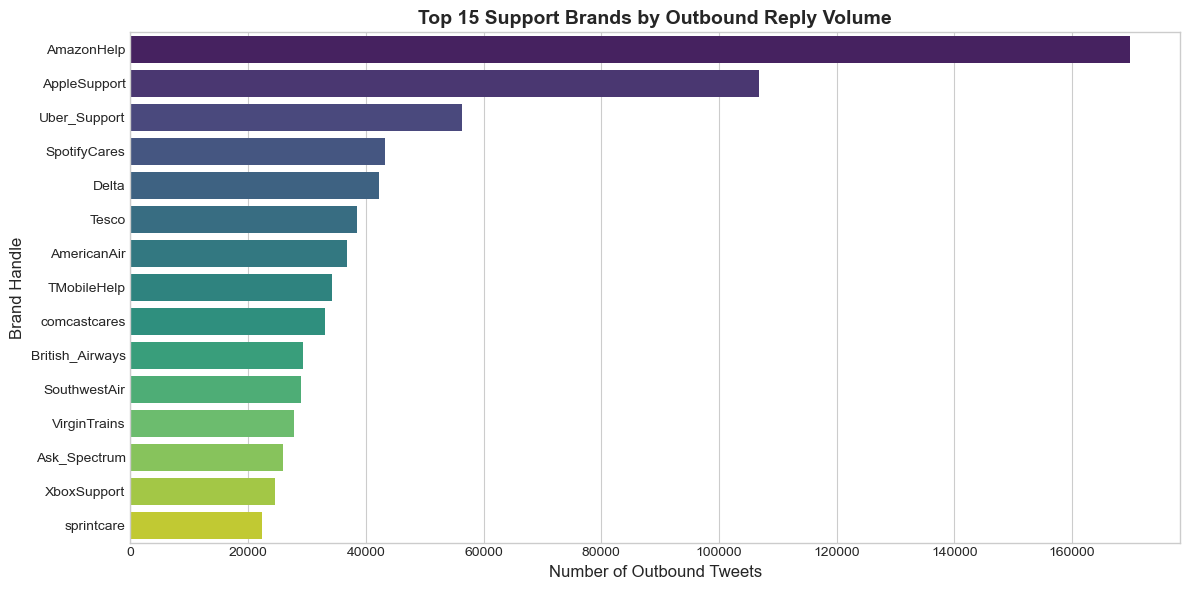

,brand,outbound_replies
0,AmazonHelp,169840
1,AppleSupport,106860
2,Uber_Support,56270
3,SpotifyCares,43265
4,Delta,42253
5,Tesco,38573
6,AmericanAir,36764
7,TMobileHelp,34317
8,comcastcares,33031
9,British_Airways,29361


In [4]:
top_brands_df = pd.DataFrame(stats['top_25_brands_by_outbound'])

plt.figure(figsize=(12, 6))
sns.barplot(data=top_brands_df.head(15), x='outbound_replies', y='brand', palette='viridis')
plt.title('Top 15 Support Brands by Outbound Reply Volume', fontsize=14, fontweight='bold')
plt.xlabel('Number of Outbound Tweets', fontsize=12)
plt.ylabel('Brand Handle', fontsize=12)
plt.tight_layout()
plt.savefig(experiments_dir / 'top_brands_volume.png', dpi=150)
plt.show()

top_brands_df.head(10)


## 4. Conversation Topology & Turn Dynamics

Understanding the structure of support conversations on Twitter is critical for conversation reconstruction and RAG index building.

C:\Windows\Temp\ipykernel_16000\867354840.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=topo_df, x='Count', y='Category', palette='mako')


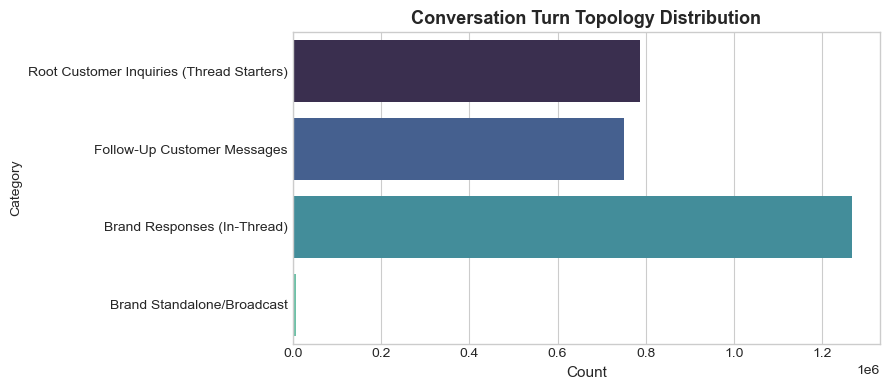

,Category,Count
0,Root Customer Inquiries (Thread Starters),787346
1,Follow-Up Customer Messages,750497
2,Brand Responses (In-Thread),1266942
3,Brand Standalone/Broadcast,6989


In [5]:
topo = stats['conversation_topology']
topo_df = pd.DataFrame([
    {'Category': 'Root Customer Inquiries (Thread Starters)', 'Count': topo['root_customer_inquiries']},
    {'Category': 'Follow-Up Customer Messages', 'Count': topo['follow_up_customer_turns']},
    {'Category': 'Brand Responses (In-Thread)', 'Count': topo['brand_in_reply_turns']},
    {'Category': 'Brand Standalone/Broadcast', 'Count': topo['brand_standalone_turns']},
])

plt.figure(figsize=(9, 4))
sns.barplot(data=topo_df, x='Count', y='Category', palette='mako')
plt.title('Conversation Turn Topology Distribution', fontsize=13, fontweight='bold')
plt.xlabel('Count', fontsize=11)
plt.tight_layout()
plt.show()

topo_df


## 5. Behavioral Signatures & Resolution Indicators

How do brands resolve issues on Twitter? Twitter support has two notable constraints:
1. **Public vs Private (DM)**: PII cannot be handled in public tweets; account issues are diverted to Direct Messages.
2. **Self-Service Links**: Public links point to troubleshooting guides, knowledge base articles, or status dashboards.
3. **Resolution Confirmations**: Customers expressing gratitude or confirming fix completion.

Brand Outbound Messages Requesting DM Escalation: 336,310 (26.4%) 
Brand Outbound Messages Providing Knowledge/Help Links: 416,589 (32.7%) 
Customer Messages with Explicit Gratitude/Resolution Cues: 157,151 


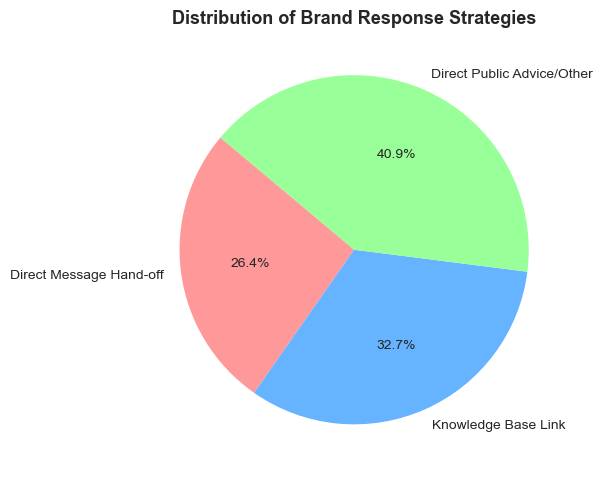

In [6]:
signals = stats['behavioral_and_resolution_signals']
print(f"Brand Outbound Messages Requesting DM Escalation: {signals['brand_dm_referrals']:,} ({signals['brand_dm_percentage']}%) ")
print(f"Brand Outbound Messages Providing Knowledge/Help Links: {signals['brand_link_referrals']:,} ({signals['brand_link_percentage']}%) ")
print(f"Customer Messages with Explicit Gratitude/Resolution Cues: {signals['customer_gratitude_signals']:,} ")

labels = ['Direct Message Hand-off', 'Knowledge Base Link', 'Direct Public Advice/Other']
dm_cnt = signals['brand_dm_referrals']
link_cnt = signals['brand_link_referrals']
other_cnt = stats['volume_breakdown']['outbound_records'] - dm_cnt - link_cnt

plt.figure(figsize=(6, 6))
plt.pie([dm_cnt, link_cnt, other_cnt], labels=labels, autopct='%1.1f%%', colors=['#ff9999','#66b3ff','#99ff99'], startangle=140)
plt.title('Distribution of Brand Response Strategies', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(experiments_dir / 'response_strategies.png', dpi=150)
plt.show()


## 6. Candidate Brand Evaluation for Phase 2

To build an effective grounded support agent, we evaluate top candidate brands across four criteria:
1. **Sufficient Volume**: Must have >40,000 interactions for rich retrieval indexing.
2. **Substantive Troubleshooting**: Technical domains with real troubleshooting steps (e.g. AppleSupport, SpotifyCares) vs order-lookup-only brands (AmazonHelp).
3. **Repetitive & Learnable Intents**: Clear software/hardware issue categories (audio, battery, updates, login, billing).
4. **Public Grounding Feasibility**: High proportion of self-contained technical guidance rather than immediate opaque DM handoffs.

| Candidate Brand | Outbound Volume | Domain | Public Troubleshooting Quality | Evaluation Assessment |
|---|---|---|---|---|
| **AppleSupport** | 106,860 | Tech / Mobile / Hardware | Very High (rich device troubleshooting, OS versions) | **Top Recommendation** |
| **AmazonHelp** | 169,840 | E-commerce / Delivery | Low (mostly "DM tracking number", "check order page") | High volume, but heavily DM-dependent |
| **Uber_Support** | 56,270 | Ride-hailing / Mobility | Medium (fare disputes, driver issues) | High emotion, requires live trip IDs |
| **SpotifyCares** | 43,265 | Streaming / Music | High (cache clearing, offline sync, app versions) | Strong technical alternative |
| **Delta** | 42,253 | Airline / Travel | Low (flight rebooking, PII, ticket lookup) | High PII requirement |


## 7. Conclusions & Next Steps

### Key Takeaways
1. The dataset contains **2,811,774 records** across **108 brands** spanning May 2008 to December 2017.
2. Data quality is exceptionally clean with **zero missing values** in core text, author, and timestamp fields.
3. **51.2% of customer inquiries are thread openers**, allowing clean conversation thread reconstruction.
4. Brand behavior shows **26.4% DM escalation** and **32.7% link sharing**, establishing clear behavioral baselines for our grounded agent.
5. **`AppleSupport`** is the premier candidate for brand selection due to its large volume (106K+ outbound turns), rich troubleshooting taxonomy, and public technical depth.

**Next Step:** Proceed to Phase 2 (Brand Selection & Formal Rationale).